linear layer weights figure out how the weights reduce the timescales of CB bias

In [11]:
# take network and look at the linear layer weights to see how they reduce the timescales of the CB bias
path = "/Users/alex/Desktop/PhD /Y1 Xmas Term/CB_PFC_Model1/draft2/draft3/cb_pfc2/Cortico-cerebellar_RNNs/results/single_task/dms_multistyle_repeats/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2"

from analysis.rebuild_model_utils import load_state_dict, find_available_Ns
Ns = find_available_Ns(path)
linear_weights = {}
for N in Ns:
    state_dict = load_state_dict(path, N)
    linear_weights[N] = state_dict["cb.dcn.weight"].cpu().numpy()


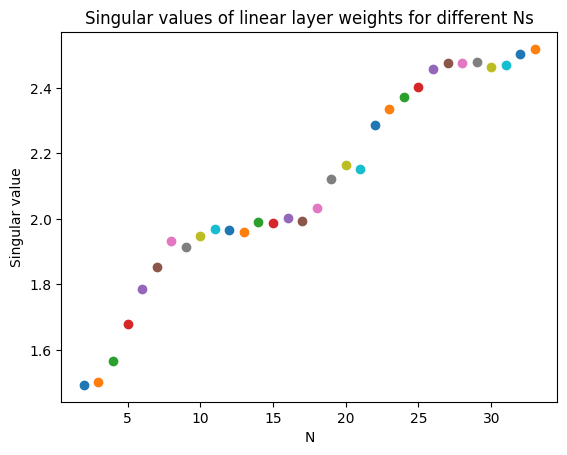

N: 2, rank: 64
N: 3, rank: 64
N: 4, rank: 64
N: 5, rank: 64
N: 6, rank: 64
N: 7, rank: 64
N: 8, rank: 64
N: 9, rank: 64
N: 10, rank: 64
N: 11, rank: 64
N: 12, rank: 64
N: 13, rank: 64
N: 14, rank: 64
N: 15, rank: 64
N: 16, rank: 64
N: 17, rank: 64
N: 18, rank: 64
N: 19, rank: 64
N: 20, rank: 64
N: 21, rank: 64
N: 22, rank: 64
N: 23, rank: 64
N: 24, rank: 64
N: 25, rank: 64
N: 26, rank: 64
N: 27, rank: 64
N: 28, rank: 64
N: 29, rank: 64
N: 30, rank: 64
N: 31, rank: 64
N: 32, rank: 64
N: 33, rank: 64


In [12]:
# for each N, calculate rank of matrix and plot singular values over Ns
import numpy as np
import matplotlib.pyplot as plt
for N in Ns:
    w = linear_weights[N]
    u, s, vh = np.linalg.svd(w)
    # plot singular values over Ns
    plt.plot(N, s[0], "o", label="largest singular value")
plt.xlabel("N")
plt.ylabel("Singular value")
plt.title("Singular values of linear layer weights for different Ns")
plt.show()

for N in Ns: 
    rank = np.linalg.matrix_rank(linear_weights[N])
    print(f"N: {N}, rank: {rank}")

plot wh and bias for each neuron in RNN only 


activity of last layer of CB and whht 

Whht and b_cb,t

see how they change over tiem

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch


def get_param(sd, key):
    """
    Return parameter from state_dict as numpy array.
    """
    if key not in sd:
        return None

    x = sd[key]
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    return np.asarray(x, dtype=float)


def collect_checkpoint_params(run_path, Ns=None):
    """
    Collect key RNN and CB parameters across checkpoints from one run.

    Parameters
    ----------
    run_path : str or Path
        Path to one run directory containing rnn_N*_N* checkpoints.
    Ns : list[int], optional
        Specific Ns to load. If None, uses all available Ns.

    Returns
    -------
    params : dict
        Dictionary containing arrays indexed by checkpoint N.
    """
    run_path = Path(run_path)

    if Ns is None:
        Ns = find_available_Ns(run_path)

    rows = {
        "N": [],

        # RNN recurrent parameters
        "hh_weight": [],
        "hh_bias": [],

        # Input parameters, optional
        "inp_weight": [],
        "inp_bias": [],

        # CB final-layer parameters, optional
        "cb_dcn_weight": [],
        "cb_dcn_bias": [],
    }

    for N in Ns:
        sd = load_state_dict(run_path, N)

        rows["N"].append(N)

        rows["hh_weight"].append(get_param(sd, "hh.weight"))
        rows["hh_bias"].append(get_param(sd, "hh.bias"))

        rows["inp_weight"].append(get_param(sd, "inp.weight"))
        rows["inp_bias"].append(get_param(sd, "inp.bias"))

        rows["cb_dcn_weight"].append(get_param(sd, "cb.dcn.weight"))
        rows["cb_dcn_bias"].append(get_param(sd, "cb.dcn.bias"))

    return rows

In [15]:
run_path = "/Users/alex/Desktop/PhD /Y1 Xmas Term/CB_PFC_Model1/draft2/draft3/cb_pfc2/Cortico-cerebellar_RNNs/results/single_task/dms_multistyle_repeats/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2"

params = collect_checkpoint_params(run_path)

print(params["N"])
print(params["hh_weight"][0].shape)
print(params["hh_bias"][0].shape)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
(64, 64)
(64,)


In [16]:
def plot_bias_heatmap_over_N(params, key="hh_bias", title=None):
    """
    Plot bias value for each neuron across saved N checkpoints.

    Parameters
    ----------
    params : dict
        Output from collect_checkpoint_params.
    key : str
        Usually "hh_bias" or "cb_dcn_bias".
    """
    Ns = np.asarray(params["N"])

    biases = params[key]

    if biases[0] is None:
        raise KeyError(f"{key} not found in these checkpoints.")

    B = np.stack(biases, axis=0)  # [num_checkpoints, hidden_size]

    plt.figure(figsize=(8, 4))
    plt.imshow(
        B.T,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
    )
    plt.colorbar(label="Bias value")
    plt.xlabel("Checkpoint")
    plt.ylabel("Neuron")
    plt.xticks(
        ticks=np.arange(len(Ns)),
        labels=Ns,
        rotation=90,
        fontsize=7,
    )

    if title is None:
        title = key

    plt.title(title)
    plt.tight_layout()
    plt.show()

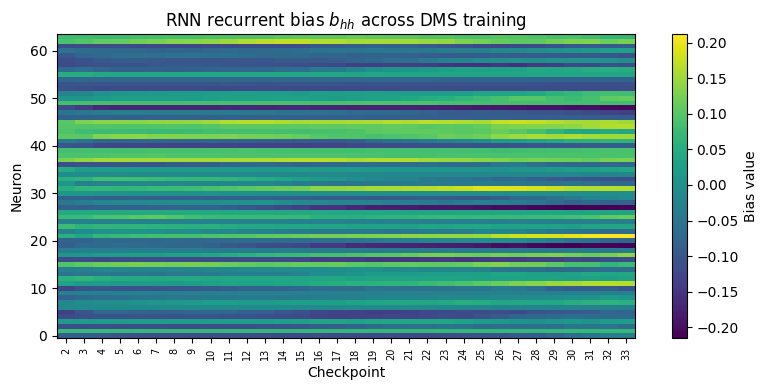

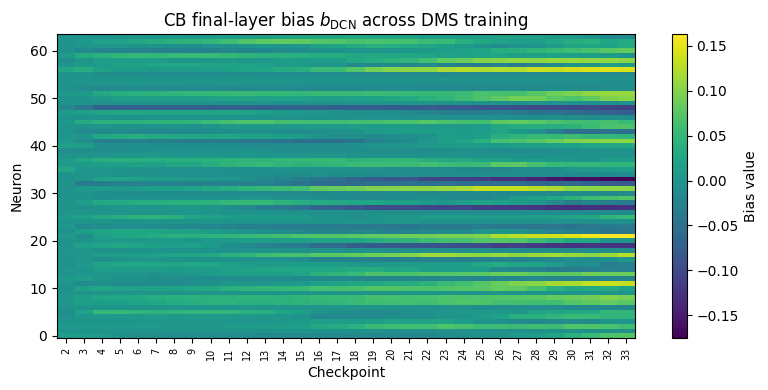

In [18]:
plot_bias_heatmap_over_N(
    params,
    key="hh_bias",
    title=r"RNN recurrent bias $b_{hh}$ across DMS training"
)
plot_bias_heatmap_over_N(
    params,
    key="cb_dcn_bias",
    title=r"CB final-layer bias $b_{\mathrm{DCN}}$ across DMS training"
)

In [19]:
import torch
import numpy as np


@torch.no_grad()
def collect_hidden_and_cb_activity(
    model,
    x,
    device="cpu",
):
    """
    Collect hidden activity, RNN recurrent drive, and CB bias over time.

    Parameters
    ----------
    model : ElmanRNNMultiHead
        Trained model.
    x : torch.Tensor
        Input sequence with shape [T, B, input_size].
    device : str
        Device.

    Returns
    -------
    activity : dict
        hidden: [T, B, H]
        rnn_drive: [T, B, H]
        input_drive: [T, B, H]
        cb_bias: [T, B, H] or None
        preact: [T, B, H]
    """
    model.eval()
    model.to(device)

    x = x.to(device).float()

    T, B, input_size = x.shape
    H = model.hh.weight.shape[0]

    h = torch.zeros(B, H, device=device)

    hidden_list = []
    rnn_drive_list = []
    input_drive_list = []
    cb_bias_list = []
    preact_list = []

    # tau / alpha handling
    if hasattr(model, "tau_param"):
        tau = model.tau_param
        alpha = 1.0 / tau
    elif hasattr(model, "tau"):
        alpha = 1.0 / model.tau
    else:
        alpha = 1.0

    for t in range(T):
        x_t = x[t]

        input_drive = model.inp(x_t)
        rnn_drive = model.hh(h)

        cb_bias = None

        if getattr(model, "use_cb_bias", False):
            if getattr(model, "cb_input_size", 0) > 0:
                cb_input = torch.cat([h, x_t], dim=-1)
            else:
                cb_input = h

            cb_bias = model.cb(cb_input)

            if getattr(model, "multiply", False):
                preact = input_drive + rnn_drive
                preact = preact * cb_bias
            else:
                preact = input_drive + rnn_drive + cb_bias
        else:
            preact = input_drive + rnn_drive

        h_new = model.afunc(preact)

        # leaky/tau update
        h = (1 - alpha) * h + alpha * h_new

        hidden_list.append(h.detach().cpu())
        rnn_drive_list.append(rnn_drive.detach().cpu())
        input_drive_list.append(input_drive.detach().cpu())
        preact_list.append(preact.detach().cpu())

        if cb_bias is not None:
            cb_bias_list.append(cb_bias.detach().cpu())

    activity = {
        "hidden": torch.stack(hidden_list, dim=0).numpy(),
        "rnn_drive": torch.stack(rnn_drive_list, dim=0).numpy(),
        "input_drive": torch.stack(input_drive_list, dim=0).numpy(),
        "preact": torch.stack(preact_list, dim=0).numpy(),
        "cb_bias": torch.stack(cb_bias_list, dim=0).numpy() if len(cb_bias_list) > 0 else None,
    }

    return activity

In [29]:
from tasks.tasks_using import make_batch_mtstyle_dms
from analysis.cb_timescales_utils import load_run_config
from analysis.rebuild_model_utils import load_state_dict, find_available_Ns, build_model_from_config_and_state


device = "cpu"

run_path = "/Users/alex/Desktop/PhD /Y1 Xmas Term/CB_PFC_Model1/draft2/draft3/cb_pfc2/Cortico-cerebellar_RNNs/results/single_task/dms_multistyle_repeats/single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2"
N = max(find_available_Ns(run_path)) # or choose a specific N, e.g. N = 12

cfg = load_run_config(run_path)
sd = load_state_dict(run_path, N)

model = build_model_from_config_and_state(cfg, sd, device)
model.load_state_dict(sd)
model.eval()

T = 100
B = 128

x, y = make_batch_mtstyle_dms(Ns=[N], bs=B)
activity = collect_hidden_and_cb_activity(
    model=model,
    x=x,
    device=device,
)

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_Whh_vs_cb_heatmaps(activity, model, sort_by="cb_var", include_rnn_bias=False):
    """
    Plot recurrent drive W_hh h_t and CB bias over time for all hidden neurons.

    Parameters
    ----------
    activity : dict
        Output of collect_hidden_and_cb_activity.
        Must contain:
            hidden:  [T, B, H]
            cb_bias: [T, B, H]

    model : torch.nn.Module
        Trained RNN / CB-RNN model containing model.hh.weight.

    sort_by : str
        "cb_var", "whh_var", "hidden_var", or None.

    include_rnn_bias : bool
        If True, plots W_hh h_t + b_hh.
        If False, plots W_hh h_t only.
    """
    hidden = activity["hidden"]      # [T, B, H]
    cb_bias = activity["cb_bias"]    # [T, B, H]

    if cb_bias is None:
        raise ValueError("No CB bias found. This looks like an RNN-only model.")

    if isinstance(hidden, torch.Tensor):
        hidden = hidden.detach().cpu().numpy()

    if isinstance(cb_bias, torch.Tensor):
        cb_bias = cb_bias.detach().cpu().numpy()

    W_hh = model.hh.weight.detach().cpu().numpy()  # [H, H]

    # W_hh h_t for each timestep and trial
    Wh_h = np.einsum("tbi,oi->tbo", hidden, W_hh)  # [T, B, H]

    if include_rnn_bias:
        b_hh = model.hh.bias.detach().cpu().numpy()  # [H]
        Wh_h = Wh_h + b_hh[None, None, :]

    whh_mean = Wh_h.mean(axis=1)       # [T, H]
    cb_mean = cb_bias.mean(axis=1)     # [T, H]
    h_mean = hidden.mean(axis=1)       # [T, H], only used for sorting if requested

    if sort_by == "cb_var":
        order = np.argsort(cb_mean.var(axis=0))[::-1]
    elif sort_by == "whh_var":
        order = np.argsort(whh_mean.var(axis=0))[::-1]
    elif sort_by == "hidden_var":
        order = np.argsort(h_mean.var(axis=0))[::-1]
    else:
        order = np.arange(whh_mean.shape[1])

    whh_plot = whh_mean[:, order]
    cb_plot = cb_mean[:, order]

    vmax = max(
        np.nanmax(np.abs(whh_plot)),
        np.nanmax(np.abs(cb_plot)),
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    im0 = axes[0].imshow(
        whh_plot.T,
        aspect="auto",
        origin="lower",
        vmin=-vmax,
        vmax=vmax,
    )

    if include_rnn_bias:
        axes[0].set_title(r"Recurrent drive $W_{hh}h_t + b_{hh}$")
    else:
        axes[0].set_title(r"Recurrent drive $W_{hh}h_t$")

    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Hidden neuron")

    im1 = axes[1].imshow(
        cb_plot.T,
        aspect="auto",
        origin="lower",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[1].set_title(r"CB bias $b_{\mathrm{CB},t}$")
    axes[1].set_xlabel("Time")

    fig.colorbar(im1, ax=axes, shrink=0.8, label="Drive / bias")
    plt.show()

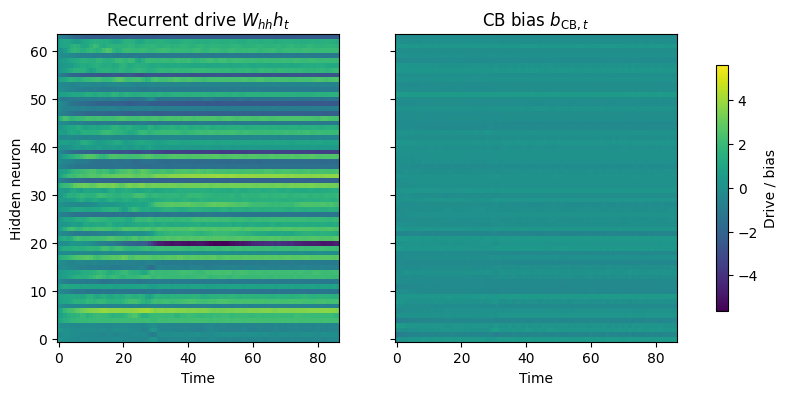

In [48]:
plot_Whh_vs_cb_heatmaps(
    activity,
    model,
    sort_by="cb_var",
    include_rnn_bias=False,
)


In [34]:
def plot_hidden_vs_cb_traces(
    activity,
    neurons=None,
    max_neurons=8,
    trial_average=True,
):
    """
    Plot h_t and b_CB,t over time for selected hidden units.
    """
    hidden = activity["hidden"]      # [T, B, H]
    cb_bias = activity["cb_bias"]    # [T, B, H]

    if cb_bias is None:
        raise ValueError("No CB bias found. This looks like an RNN-only model.")

    if trial_average:
        h = hidden.mean(axis=1)      # [T, H]
        cb = cb_bias.mean(axis=1)    # [T, H]
    else:
        h = hidden[:, 0, :]
        cb = cb_bias[:, 0, :]

    if neurons is None:
        # choose neurons where CB bias changes most over time
        cb_var = cb.var(axis=0)
        neurons = np.argsort(cb_var)[-max_neurons:][::-1]
    else:
        neurons = neurons[:max_neurons]

    fig, axes = plt.subplots(
        len(neurons),
        1,
        figsize=(7, 1.7 * len(neurons)),
        sharex=True,
    )

    if len(neurons) == 1:
        axes = [axes]

    for ax, n in zip(axes, neurons):
        ax.plot(h[:, n], label=fr"$h_t$, unit {n}")
        ax.plot(cb[:, n], linestyle="--", label=fr"$b_{{CB,t}}$, unit {n}")
        ax.axhline(0, linewidth=0.8)
        ax.set_ylabel(f"Unit {n}")
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Time")
    fig.suptitle("Hidden activity versus CB bias", y=1.01)
    plt.tight_layout()
    plt.show()

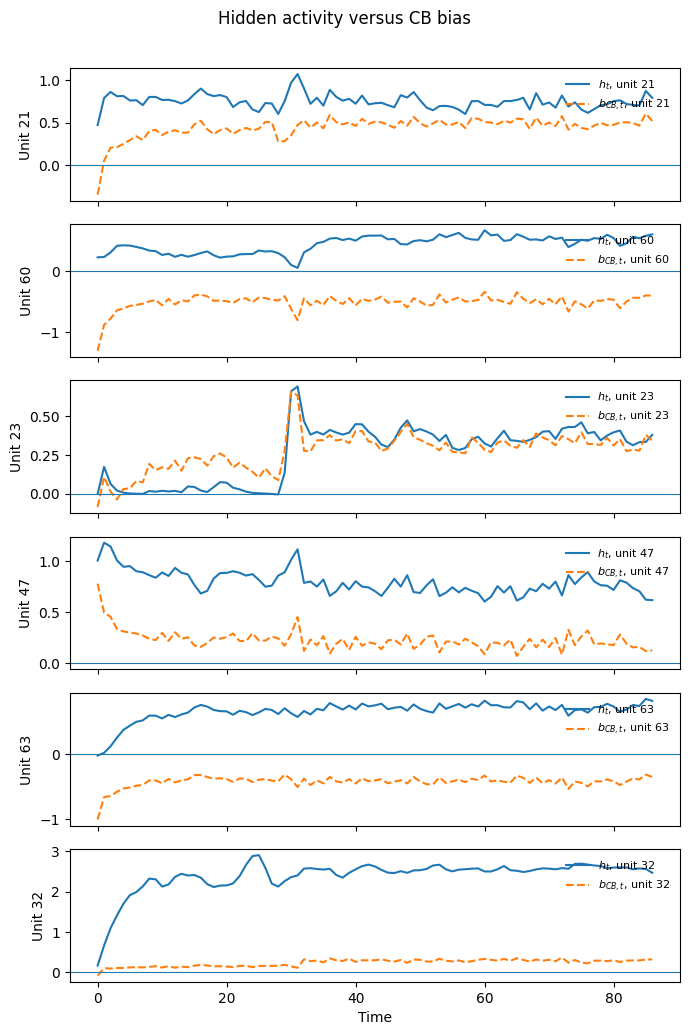

In [35]:
plot_hidden_vs_cb_traces(activity, max_neurons=6)

take big CB GC model and fit timescales and dimensioanltiy

In [36]:
from pathlib import Path
import pandas as pd
import sys
from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity
from analysis.activity_analysis import summarize_multi_runs_pca_for_multi_keys

COMMON_KWARGS = dict(
    keys=["hidden", "gc", "pc", "cb_bias"],
    batch_size=64,
    n_batches=10,
    head_idx=0,
    device="cpu",
)
RESULTS_DIR = Path("/Users/alex/Desktop/PhD /Y1 Xmas Term/CB_PFC_Model1/draft2/draft3/cb_pfc2/Cortico-cerebellar_RNNs/results")
def make_network_paths(base_dir, pattern, networks=(1, 2, 3)):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    },


    ("parity", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    },
}


results = {}

for (task, regime), cfg in RUN_GROUPS.items():
    print(f"Running PCA summary: task={task}, regime={regime}")

    df = summarize_multi_runs_pca_for_multi_keys(
        run_paths=cfg["paths"],
        batch_fn=cfg["batch_fn"],
        **COMMON_KWARGS,
    )

    df["task"] = task
    df["regime"] = regime

    results[(task, regime)] = df


all_pca_df = pd.concat(results.values(), ignore_index=True)

Running PCA summary: task=dms, regime=simultaneous
Processing run 1/3: single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 2/3: single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Processing run 3/3: single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Running PCA for N=20
Running PCA for N=30
Running PCA for N=10
Runn

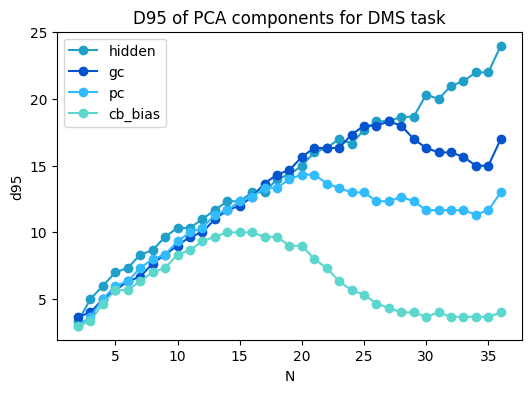

In [44]:
all_df_cb_dms = results[("dms", "simultaneous")]
all_df_cb_parity = results[("parity", "simultaneous")]
# plot d95 
full_color_map = {
    "hidden":  "#20A0C9",
    "gc":      "#0553CF",
    "pc":      "#33BBFF",
    "cb_bias": "#5BD7CD",
}
preferred_order = ["hidden", "gc", "pc", "cb_bias"]
populations = list(all_df_cb_dms["population"].unique())
# plot averaged d95 for each population, with populations in preferred order
plt.figure(figsize=(6, 4))
for pop in preferred_order:
    if pop not in populations:
        continue
    # average over network repeats, not Ns or time
    d95_mean = all_df_cb_dms[all_df_cb_dms["population"] == pop].groupby("N")["d95"].mean()
    plt.plot(d95_mean.index, d95_mean.values, label=pop,marker='o', color=full_color_map.get(pop, None))
plt.xlabel("N")
plt.ylabel("d95")
plt.title("D95 of PCA components for DMS task")
plt.legend()
plt.show()


In [49]:
from pathlib import Path
import pandas as pd

from analysis.timescales import summarize_timescale_multiple_runs, average_across_runs_timescales


NETWORKS = (1, 2, 3)


def make_network_paths(base_dir, pattern, networks=NETWORKS):
    base_dir = RESULTS_DIR / base_dir
    return [str(base_dir / pattern.format(i=i)) for i in networks]


RUN_GROUPS = {
    ("dms", "simultaneous"): make_network_paths(
        "single_task/dms_multistyle_repeats",
        "single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
    ("parity", "simultaneous"): make_network_paths(
        "single_task/parity_multistyle_repeats",
        "single_parity_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
    ),
}

timescale_runs = {}
avg_timescales = {}

for (task, regime), paths in RUN_GROUPS.items():
    print(f"Processing timescales: task={task}, regime={regime}")

    df_runs = summarize_timescale_multiple_runs(paths)
    df_runs["task"] = task
    df_runs["regime"] = regime

    df_avg = average_across_runs_timescales(df_runs)
    df_avg["task"] = task
    df_avg["regime"] = regime

    timescale_runs[(task, regime)] = df_runs
    avg_timescales[(task, regime)] = df_avg

Processing timescales: task=dms, regime=simultaneous


FileNotFoundError: No timescales_N*.pkl files found in:
/Users/alex/Desktop/PhD /Y1 Xmas Term/CB_PFC_Model1/draft2/draft3/cb_pfc2/Cortico-cerebellar_RNNs/results/single_task/dms_multistyle_repeats/single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_1/timescales

In [ ]:
python analysis/run_cb_timescales.py \
  --run_dir "results/single_task/dms_multistyle_repeats/single_dms_elman_size_64_CB_gc512_RNNlr0.01_CBlr0.01_CBinput_simult_network_1" \
  --mode legacy_single \
  --device cpu \
  --T 20000 \
  --burn_T 500 \
  --batch_size 8 \
  --max_lag 200 \
  --fit_lag 30